# Biomanufacturing Process Analysis: Producing Enzymes and Biological Products

**Estimated Time**: 90–105 Minutes

This notebook uses simulated **industrial fermentation batch data** (IndPenSim) to explore how biotechnology companies monitor manufacturing quality and product yield.

Instructor: Eduardo Ayala

Contributors: Ariana Ghimire


## Learning objectives

By the end of this notebook, you should be able to:

1. Explain what biomanufacturing is and why companies use it to produce enzymes and biological products.
2. Use Python to explore batch manufacturing data.
3. Compare product yield across different production batches.
4. Identify faulty or abnormal batches using data visualizations.
5. Analyze which batches produced the most product.
6. Interpret how data analysis can support quality control in biotechnology.
7. Explore time-series process data to understand what happens inside a batch while it is running.


### Table of Contents

1. Introduction to Biomanufacturing
2. Load the Data
3. Explore the Dataset
4. Visualizing Product Yield Across Batches
5. Comparing Product Collected During vs. End of Batch
6. Faulty vs. Non-Faulty Batches
7. Identifying High-Yield and Low-Yield Batches
8. Looking Inside a Biomanufacturing Batch Over Time


---

> **Run the cell below before running any other code cells!**


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from IPython.display import display

%matplotlib inline


---

## Section 1: Introduction to Biomanufacturing

**Biomanufacturing** is the process of using living cells or biological systems to produce useful products. These products can include **enzymes**, medicines, vaccines, antibodies, proteins, and other biological materials used in research, healthcare, and industry.

In this notebook, you act as a **process scientist** at a biotechnology company. Your job is to analyze batch data from a biomanufacturing process and determine:

- Which batches produced the most product
- Which batches may have had problems during production

### Important framing

- The dataset comes from a **simulated industrial fermentation** process (IndPenSim).
- **Fermentation** is commonly used in biotechnology to grow microorganisms or cells that produce valuable biological products.
- In real companies, scientists monitor batches carefully because **failed batches** can waste time, money, and materials.
- This notebook focuses on the **manufacturing process**—not on making DNA directly. Enzymes and other biological products made in fermentation may later support research, medicine, or DNA-related workflows.

> **Note:** The example product in the simulation is penicillin, but the **same types of data analysis** apply when companies manufacture enzymes, proteins, and other biological products.


**Checkpoint:** Why might a biotech company want to analyze manufacturing data *before* a batch is finished?



*Your answers here*

---

## Section 2: Load the Data

Run the cell below to load the batch **statistics** file. Each row is one completed manufacturing **batch**.


In [59]:
stats = pd.read_csv("100_Batches_IndPenSim_Statistics.csv")
stats.head()


,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
0,1,1066400.0,1720000.0,2786400.0,0
1,2,985910.0,1340100.0,2326000.0,0
2,3,1416100.0,1259200.0,2675300.0,0
3,4,815700.0,1071000.0,1886700.0,0
4,5,1128500.0,2434400.0,3562900.0,0


### Column guide

| Column | Meaning |
|--------|---------|
| `Batch ref` | Batch number (1–100) |
| `Penicllin_harvested_during_batch(kg)` | Product collected **during** the batch |
| `Penicllin_harvested_end_of_batch (kg)` | Product collected at the **end** of the batch |
| `Penicllin_yield_total (kg)` | **Total** product yield for the batch |
| `Fault ref(0-NoFault 1-Fault)` | `0` = no fault, `1` = fault detected |

Think of **yield** as how much usable biological product the batch produced.


---

## Section 3: Explore the Dataset

Before we graph the data, it helps to check the **structure** of the table and a few **summary numbers** for each column.

When you run `stats.info()`, pandas shows a small data dictionary:

| Term | What it means |
|------|----------------|
| **Non-null count** | How many rows have a real value in that column (not missing). Here, `100 non-null` means all 100 batches have a value. |
| **Null** | A **missing** value (blank in the spreadsheet). Pandas often shows this as `NaN`. If non-null count is less than the number of rows, some values are null. |
| **Dtype** (data type) | What kind of values the column stores—for example `int64` (whole numbers like batch ID or fault flag) or `float64` (numbers that can have decimals, like yield in kg). |

Run the next cell to see how many batches we have, the column types from `info()`, and **summary statistics** (`describe()`). We keep only the main summaries—**count, mean, standard deviation (std), min, and max**—not the 25%, 50%, and 75% rows.


In [60]:
print("Number of batches:", stats.shape[0])
print("Number of columns:", stats.shape[1])
print()
stats.info()
print()
stats.describe(percentiles=[])


Number of batches: 100
Number of columns: 5

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Batch ref                              100 non-null    int64  
 1   Penicllin_harvested_during_batch(kg)   100 non-null    float64
 2   Penicllin_harvested_end_of_batch (kg)  100 non-null    float64
 3   Penicllin_yield_total (kg)             100 non-null    float64
 4   Fault ref(0-NoFault 1-Fault)           100 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.0 KB



,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
count,100.000000,1.000000e+02,1.000000e+02,1.000000e+02,100.000000
mean,50.500000,1.108662e+06,1.920394e+06,3.029064e+06,0.100000
std,29.011492,2.668074e+05,5.814616e+05,7.508168e+05,0.301511
min,1.000000,3.886500e+05,5.021800e+05,8.908300e+05,0.000000
max,100.000000,2.089700e+06,2.932400e+06,4.447700e+06,1.000000


**Questions (answer in your own words):**

1. How many batches are in the dataset?
2. How many variables are recorded?
3. Which column tells us the total amount of product made?
4. Which column tells us whether the batch had a fault?


*Your answers here*

### Your Turn: Average total yield

Calculate the **average total product yield** across all batches.
<details>
<summary><b>Hint</b></summary>

Use `.mean()` on the total yield column: `stats["column_name"].mean()`

</details>



<details>
<summary><b>Answer</b></summary>

Use `.mean()` on the total yield column: `stats["Penicllin_yield_total (kg)"].mean()`

</details>


In [80]:
average_yield = ...
average_yield


Ellipsis

**Checkpoint:** Use your `average_yield` result and the `describe()` table for `Penicllin_yield_total (kg)` to answer:

1. **Compare the averages:** Does the **mean** row in `describe()` match your `average_yield` value (or come very close)? What does that tell you about using `.mean()` vs. reading the mean from `describe()`?

2. **Look at the range:** What are the **min** and **max** total yields (in kg)? Is your average about halfway between them, or closer to one end?

3. **Look at spread:** What is the **std** (standard deviation)? In your own words, do the batches seem **similar** in yield or **quite different** from each other?

4. **Typical performance:** Based on the mean, min, max, and std, describe what a **typical** batch might produce. Can every batch be expected to hit exactly the average? Why or why not?



*Your answers here* - good answer example will delete later "The average (~3.03M kg) matches the mean in describe(). Yields range from about 0.89M to 4.45M kg, so batches vary a lot. The average is a useful “typical” value, but many batches are above or below it—so the process isn’t perfectly consistent, which is why companies monitor batches and faults."


### See the distribution

A **histogram** groups batches by similar yield values so you can check your numbers visually. Each bar shows how many batches fall in that yield range. The dashed line marks the **mean** you calculated—compare it to where most bars appear.

Run the cell below after you finish the checkpoint questions above.

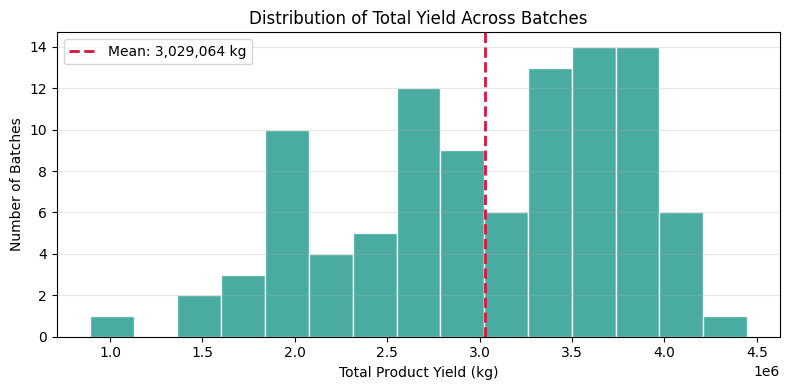

In [62]:
yield_col = "Penicllin_yield_total (kg)"
mean_yield = stats[yield_col].mean()

plt.figure(figsize=(8, 4))
plt.hist(stats[yield_col], bins=15, color="#2a9d8f", edgecolor="white", alpha=0.85)
plt.axvline(
    mean_yield,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_yield:,.0f} kg",
)
plt.xlabel("Total Product Yield (kg)")
plt.ylabel("Number of Batches")
plt.title("Distribution of Total Yield Across Batches")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---

## Section 4: Visualizing Product Yield Across Batches

In biomanufacturing, one major goal is **consistency**. Companies want batches to produce similar amounts of product. If some batches produce much less (or much more), scientists investigate why.

Run the cell below for an **interactive** line chart (using [Plotly](https://plotly.com/python/)). **Hover** over any point to see that batch's total yield, harvest amounts, and fault status—no separate dropdown needed.


In [63]:
yield_col = "Penicllin_yield_total (kg)"

plot_df = stats.copy()
plot_df["Batch Status"] = plot_df["Fault ref(0-NoFault 1-Fault)"].map(
    {0: "No Fault", 1: "Fault"}
)

fig = px.line(
    plot_df,
    x="Batch ref",
    y=yield_col,
    markers=True,
    hover_data={
        "Penicllin_harvested_during_batch(kg)": ":,.0f",
        "Penicllin_harvested_end_of_batch (kg)": ":,.0f",
        "Batch Status": True,
        "Fault ref(0-NoFault 1-Fault)": False,
        yield_col: ":,.0f",
    },
    labels={
        "Batch ref": "Batch Number",
        yield_col: "Total Product Yield (kg)",
    },
    title="Total Product Yield Across Manufacturing Batches",
)
# "closest" = highlight one point at a time (no vertical crosshair / dotted spike line)
fig.update_layout(
    hovermode="closest",
    height=450,
    hoverlabel=dict(bgcolor="white", font_size=12),
)
fig.update_xaxes(showspikes=False)
fig.update_yaxes(showspikes=False)
fig.update_traces(
    mode="lines+markers",
    line=dict(color="rgba(42, 157, 143, 0.35)", width=1.5),
    marker=dict(size=8, color="#2a9d8f", line=dict(width=1, color="white")),
    # Plotly enlarges/outlines the point under the cursor on hover (no extra property needed)
)

import plotly.io as pio
if "vscode" in pio.renderers:
    pio.renderers.default = "vscode"
fig.show()


**Questions:**

1. Do all batches produce the same amount?
2. Which batches seem unusually low or high?
3. Why would consistency matter in biotech manufacturing?
4. What do you notice about how spread out the yields are?


*Your answer here*


---

## Section 5: Comparing Product Collected During vs. End of Batch

Some product is collected **during** the batch, and some at the **end**. Comparing these values helps you see that biomanufacturing is not only about the final number—scientists also care about what happens **during** the process.


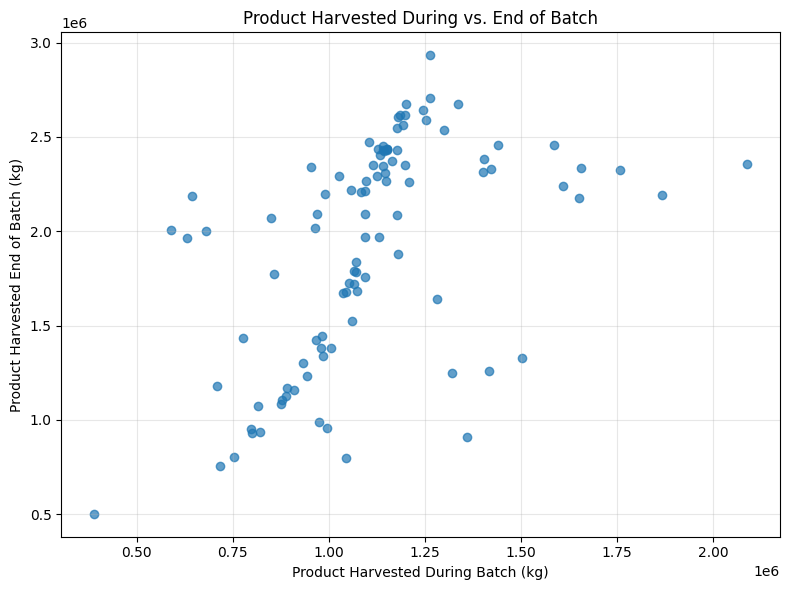

In [64]:
plt.figure(figsize=(8, 6))
plt.scatter(
    stats["Penicllin_harvested_during_batch(kg)"],
    stats["Penicllin_harvested_end_of_batch (kg)"],
    alpha=0.7,
)
plt.xlabel("Product Harvested During Batch (kg)")
plt.ylabel("Product Harvested End of Batch (kg)")
plt.title("Product Harvested During vs. End of Batch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Correlation review

**Correlation** measures how strongly two variables **move together** in a straight-line pattern. Values range from **-1 to +1**:

| Value | What it suggests |
|-------|------------------|
| **+1** | Strong **positive** relationship: when one variable goes up, the other tends to go up too. |
| **Near 0** | **Weak** linear relationship: knowing one variable does not tell you much about the other. |
| **-1** | Strong **negative** relationship: when one goes up, the other tends to go down. |

**How to read the heatmap below:**

- Each **square** is the correlation between two harvest variables.
- **Darker green** → correlation closer to **+1** (more strongly move together).
- **Darker red** → correlation closer to **-1** (move in opposite directions).
- The **diagonal** (top-left to bottom-right) is always **1.00**—each variable is perfectly correlated with itself.
- The number in each cell is the correlation value (rounded to two decimals).

**Important:** Correlation describes a **pattern** in the data. It does **not** prove that one variable *causes* the other.

Run the cell below to build a **correlation heatmap** for the three harvest variables.


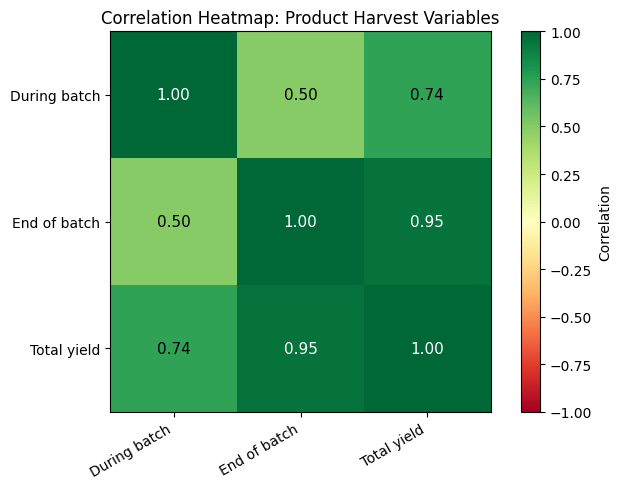

In [65]:
harvest_cols = [
    "Penicllin_harvested_during_batch(kg)",
    "Penicllin_harvested_end_of_batch (kg)",
    "Penicllin_yield_total (kg)",
]

short_labels = [
    "During batch",
    "End of batch",
    "Total yield",
]

corr = stats[harvest_cols].corr()
corr.index = short_labels
corr.columns = short_labels

fig, ax = plt.subplots(figsize=(7, 5))
heatmap = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=30, ha="right")
ax.set_yticklabels(short_labels)

for row in range(len(short_labels)):
    for col in range(len(short_labels)):
        value = corr.iloc[row, col]
        ax.text(
            col,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black" if abs(value) < 0.75 else "white",
            fontsize=11,
        )

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("Correlation")
ax.set_title("Correlation Heatmap: Product Harvest Variables")
plt.tight_layout()
plt.show()


**Questions:**

1. Do batches with higher during-batch harvest also tend to have higher end-of-batch harvest?
2. What might this tell us about the production process?


<details>
<summary><b>Hint</b></summary>

On the heatmap, look at the square for **During batch** vs **End of batch**. Is the number positive and fairly green? That supports a positive relationship. Correlation does not prove cause-and-effect, but it can suggest patterns worth investigating.

</details>


*Your answer here*

---

## Section 6: Faulty vs. Non-Faulty Batches

In real biomanufacturing, a **fault** means something went wrong—such as contamination, sensor issues, oxygen changes, feed problems, or temperature deviations.

The `Fault ref` column uses **0** for no fault and **1** for a fault. Run the cells below to **count** how many batches fall in each group, then compare yields with a **boxplot**.


In [66]:
fault_col = "Fault ref(0-NoFault 1-Fault)"
stats[fault_col].value_counts().sort_index()


Fault ref(0-NoFault 1-Fault)
0    90
1    10
Name: count, dtype: int64

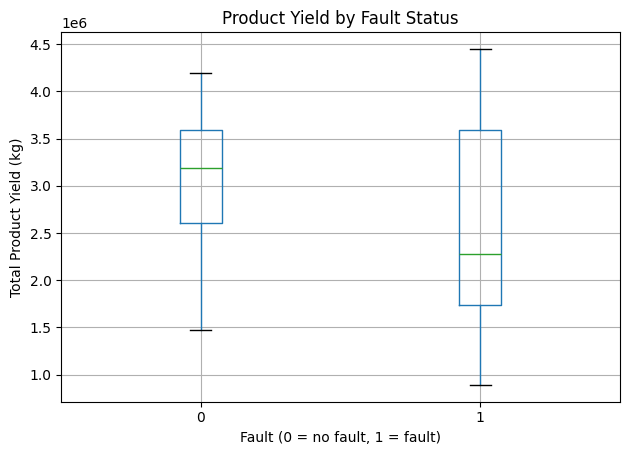

In [67]:
fault_col = "Fault ref(0-NoFault 1-Fault)"
yield_col = "Penicllin_yield_total (kg)"

stats.boxplot(column=yield_col, by=fault_col)
plt.suptitle("")
plt.xlabel("Fault (0 = no fault, 1 = fault)")
plt.ylabel("Total Product Yield (kg)")
plt.title("Product Yield by Fault Status")
plt.tight_layout()
plt.show()


**Questions:** Using the counts and boxplot, do faulty batches (`1`) tend to have lower yield than non-faulty batches (`0`)? In one or two sentences, what do you notice?

*Your answer here*


---

## Section 7: Identifying High-Yield and Low-Yield Batches

Process scientists often compare successful and unsuccessful batches to understand what went differently.


In [68]:
top_batches = stats.sort_values("Penicllin_yield_total (kg)", ascending=False).head(5)
low_batches = stats.sort_values("Penicllin_yield_total (kg)", ascending=True).head(5)

print("Top 5 batches by yield:")
display(top_batches)
print("Bottom 5 batches by yield:")
display(low_batches)


Top 5 batches by yield:


,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
92,93,2089700.0,2357900.0,4447700.0,1
31,32,1263600.0,2932400.0,4196000.0,0
8,9,1757800.0,2325300.0,4083100.0,0
56,57,1866500.0,2192600.0,4059100.0,0
84,85,1587000.0,2457300.0,4044300.0,0


Bottom 5 batches by yield:


,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
98,99,388650.0,502180.0,890830.0,1
43,44,716550.0,757550.0,1474100.0,0
99,100,753080.0,801930.0,1555000.0,1
97,98,799760.0,930830.0,1730600.0,1
91,92,798360.0,954230.0,1752600.0,1


### Your Turn

In the code cell below, find:

- The **highest-yield** batch number and its total yield
- The **lowest-yield** batch number and its total yield
- Whether each batch had a fault (`0` or `1`)

<details>
<summary><b>Hint</b></summary>

Example approach:<br>`stats.loc[stats["column_name"].idxmax()]` gives the full row for the highest-yield batch.

</details>

<details>
<summary><b>Answer</b></summary>

Example approach:<br>`stats.loc[stats["Penicllin_yield_total (kg)"].idxmax()]` gives the full row for the highest-yield batch.
<br>`stats.loc[stats["Penicllin_yield_total (kg)"].idxmin()]` gives the full row for the lowest-yield batch.

</details>



In [81]:
# Your code here — try using .idxmax(), .idxmin(), or .sort_values()

highest_yield_batch = ...
lowest_yield_batch = ...
print(lowest_yield_batch)

Ellipsis


**Reflection:** What patterns do you notice between fault status (`0` = no fault, `1` = fault) and product yield?



*Your answer here*


---

## Section 8: Looking Inside a Biomanufacturing Batch Over Time

In the earlier sections, you analyzed **one row per batch**. Now you will look **inside individual batches over time** to understand what happens during the biomanufacturing process.

This section uses a smaller teaching sample extracted from the full IndPenSim time-series dataset. It includes only a few batches and the most student-friendly process columns.


### Section 8.1: Load the Time-Series Data

So far, we have looked at final batch results. But in real biomanufacturing, scientists monitor the batch **while it is running**.

They track process variables like oxygen, pH, temperature, carbon dioxide, and product concentration to make sure the cells are healthy and the product is forming correctly.


In [70]:
timeseries = pd.read_csv("data/teaching_batches_timeseries.csv")
timeseries.head()


,Time (h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),carbon dioxide percent in off-gas(CO2outgas:%),Sugar feed rate(Fs:L/h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Oxygen Uptake Rate(OUR:(g min^{-1})),Offline Biomass concentratio(X_offline:X(g L^{-1})),Fault reference(Fault_ref:Fault ref),Batch_Number
0,0.2,0.95749,14.711,1.017800e-25,6.4472,298.22,0.089514,8.0,30.0,100.0,0.480510,NaN,0.0,1
1,0.4,1.00460,14.699,1.000000e-03,6.4932,298.17,0.101760,8.0,30.0,100.0,0.058147,NaN,0.0,1
2,0.6,1.04980,14.686,9.993400e-04,6.5425,298.14,0.105800,8.0,30.0,100.0,-0.041505,NaN,0.0,1
3,0.8,1.09420,14.661,9.987400e-04,6.5753,298.11,0.108190,8.0,30.0,100.0,-0.056737,NaN,0.0,1
4,1.0,1.13700,14.633,9.982100e-04,6.5825,298.09,0.110300,8.0,30.0,100.0,-0.049975,0.52808,0.0,1


**Question**

- Why might scientists want measurements over time instead of only final yield?


*Your answers here*


### Section 8.2: Choose One Batch to Investigate

Change `selected_batch` in the code cell below to one of the available batch numbers (`1`, `44`, `93`, or `99`), then re-run the cell. Re-run the plotting cells in Sections 8.3–8.5 after you change the batch.


In [71]:
selected_batch = 1  # change to 1, 44, 93, or 99 and re-run this cell

batch_data = timeseries[timeseries["Batch_Number"] == selected_batch]
print(f"Available batches: {sorted(timeseries['Batch_Number'].astype(int).unique())}")
print(f"Showing batch {selected_batch} ({len(batch_data)} rows)\n")
batch_data.head()


Available batches: [np.int64(1), np.int64(44), np.int64(93), np.int64(99)]
Showing batch 1 (1130 rows)



,Time (h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),carbon dioxide percent in off-gas(CO2outgas:%),Sugar feed rate(Fs:L/h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Oxygen Uptake Rate(OUR:(g min^{-1})),Offline Biomass concentratio(X_offline:X(g L^{-1})),Fault reference(Fault_ref:Fault ref),Batch_Number
0,0.2,0.95749,14.711,1.017800e-25,6.4472,298.22,0.089514,8.0,30.0,100.0,0.480510,NaN,0.0,1
1,0.4,1.00460,14.699,1.000000e-03,6.4932,298.17,0.101760,8.0,30.0,100.0,0.058147,NaN,0.0,1
2,0.6,1.04980,14.686,9.993400e-04,6.5425,298.14,0.105800,8.0,30.0,100.0,-0.041505,NaN,0.0,1
3,0.8,1.09420,14.661,9.987400e-04,6.5753,298.11,0.108190,8.0,30.0,100.0,-0.056737,NaN,0.0,1
4,1.0,1.13700,14.633,9.982100e-04,6.5825,298.09,0.110300,8.0,30.0,100.0,-0.049975,0.52808,0.0,1


### Section 8.3: Product Concentration Over Time

Product concentration tells us how much biological product is building up inside the bioreactor. In this dataset, the example product is penicillin, but the same type of analysis can apply to enzymes, proteins, and other biological products.

### Your Turn

Complete the `plt.plot(...)` line in the code cell below to plot **product concentration over time** for the batch you selected in Section 8.2.

<details>
<summary><b>Hint</b></summary>

A line plot needs an x-axis and a y-axis.<br>
Use `batch_data["Time (h)"]` for time on the x-axis.<br>
Look at `batch_data.columns` to find the column for penicillin (product) concentration.

</details>

<details>
<summary><b>Answer</b></summary>

```python
plt.plot(batch_data["Time (h)"], batch_data["Penicillin concentration(P:g/L)"])
```

</details>


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(...)  # complete this line
plt.xlabel("Time (hours)")
plt.ylabel("Product Concentration (g/L)")
plt.title(f"Product Concentration Over Time for Batch {selected_batch}")
plt.show()


**Questions:**

- Does product concentration increase over time?
- Around what time does production seem to speed up?
- Does production eventually level off?


*Your answers here*


### Section 8.4: Dissolved Oxygen Over Time

Cells need oxygen to grow and produce biological products. **Dissolved oxygen** tells us how much oxygen is available in the bioreactor.

### Your Turn

Complete the `plt.plot(...)` line in the code cell below to plot **dissolved oxygen over time** for your selected batch.

<details>
<summary><b>Hint</b></summary>

Use `batch_data["Time (h)"]` for the x-axis.<br>
The dissolved oxygen column name starts with `Dissolved oxygen concentration`.

</details>

<details>
<summary><b>Answer</b></summary>

```python
plt.plot(batch_data["Time (h)"], batch_data["Dissolved oxygen concentration(DO2:mg/L)"])
```

</details>


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(...)  # complete this line
plt.xlabel("Time (hours)")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.title(f"Dissolved Oxygen Over Time for Batch {selected_batch}")
plt.show()


**Questions:**

- Does dissolved oxygen stay constant or change?
- What might happen if oxygen becomes too low?
- Why would oxygen monitoring matter in enzyme or protein production?


*Your answers here*


### Section 8.5: pH and Temperature Monitoring

Biomanufacturing conditions need to be controlled carefully. If pH or temperature moves too far from the ideal range, cells may grow poorly or produce less product.

### Your Turn

Complete the `plt.plot(...)` lines in the two code cells below:

1. Plot **pH over time**
2. Plot **temperature over time**

<details>
<summary><b>Hint</b></summary>

For both plots, use `batch_data["Time (h)"]` on the x-axis.<br>
For pH, use the column named `pH(pH:pH)`.<br>
For temperature, use the column named `Temperature(T:K)`.

</details>

<details>
<summary><b>Answer</b></summary>

pH plot:
```python
plt.plot(batch_data["Time (h)"], batch_data["pH(pH:pH)"])
```

Temperature plot:
```python
plt.plot(batch_data["Time (h)"], batch_data["Temperature(T:K)"])
```

</details>


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(...)  # complete this line — plot pH over time
plt.xlabel("Time (hours)")
plt.ylabel("pH")
plt.title(f"pH Over Time for Batch {selected_batch}")
plt.show()


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(...)  # complete this line — plot temperature over time
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (K)")
plt.title(f"Temperature Over Time for Batch {selected_batch}")
plt.show()


**Questions:**

- Which variable seems more stable: pH or temperature?
- Why might stable conditions be important in biomanufacturing?


*Your answers here*

### Section 8.6: Compare a High-Yield and Low-Yield Batch

Use the high-yield and low-yield batches you identified in Section 7.


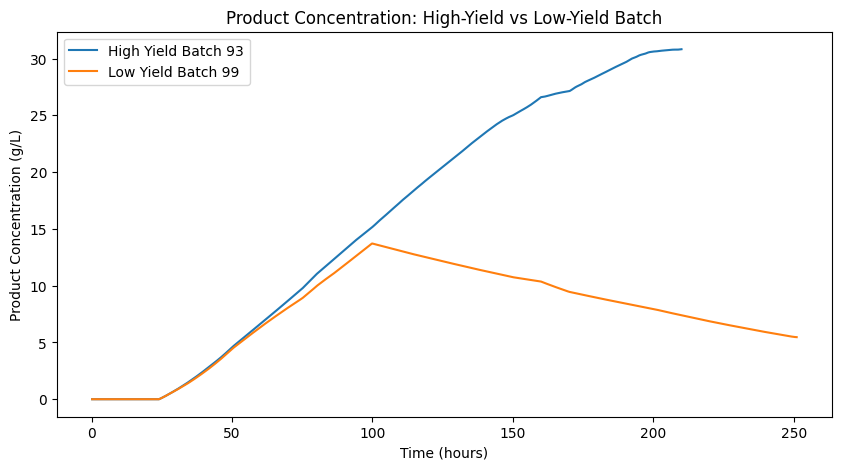

In [77]:
high_yield_batch = int(top_batches["Batch ref"].iloc[0])
low_yield_batch = int(low_batches["Batch ref"].iloc[0])

high_data = timeseries[timeseries["Batch_Number"] == high_yield_batch]
low_data = timeseries[timeseries["Batch_Number"] == low_yield_batch]

plt.figure(figsize=(10, 5))
plt.plot(
    high_data["Time (h)"],
    high_data["Penicillin concentration(P:g/L)"],
    label=f"High Yield Batch {high_yield_batch}",
)
plt.plot(
    low_data["Time (h)"],
    low_data["Penicillin concentration(P:g/L)"],
    label=f"Low Yield Batch {low_yield_batch}",
)
plt.xlabel("Time (hours)")
plt.ylabel("Product Concentration (g/L)")
plt.title("Product Concentration: High-Yield vs Low-Yield Batch")
plt.legend()
plt.show()


**Questions:**

- Which batch reaches a higher product concentration?
- Do the batches start differently or become different later?
- Why is it useful to compare batches over time?



*Your answers here*


### Section 8.7: Compare Process Conditions

Change `selected_variable` in the code cell below to compare a different process measurement between the high-yield and low-yield batches.


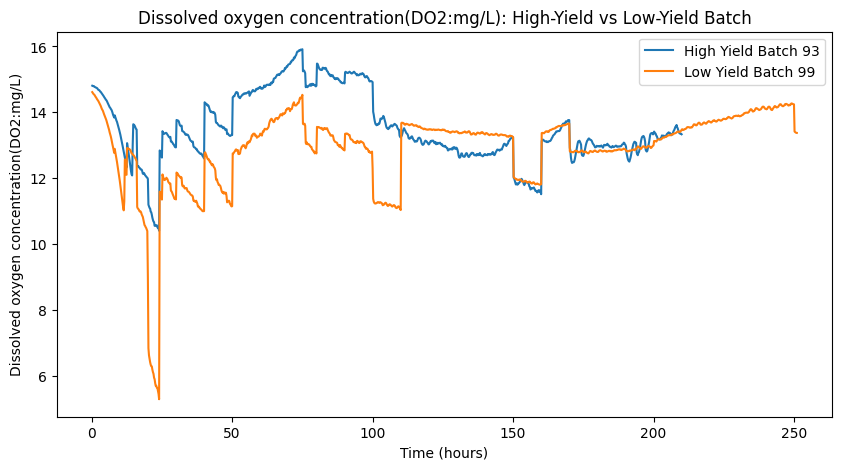

In [78]:
selected_variable = "Dissolved oxygen concentration(DO2:mg/L)"
# other options:
# "pH(pH:pH)"
# "Temperature(T:K)"
# "carbon dioxide percent in off-gas(CO2outgas:%)"
# "Sugar feed rate(Fs:L/h)"
# "Oxygen Uptake Rate(OUR:(g min^{-1}))"

plt.figure(figsize=(10, 5))
plt.plot(
    high_data["Time (h)"],
    high_data[selected_variable],
    label=f"High Yield Batch {high_yield_batch}",
)
plt.plot(
    low_data["Time (h)"],
    low_data[selected_variable],
    label=f"Low Yield Batch {low_yield_batch}",
)
plt.xlabel("Time (hours)")
plt.ylabel(selected_variable)
plt.title(f"{selected_variable}: High-Yield vs Low-Yield Batch")
plt.legend()
plt.show()


**Question:**

- Which process variable seems most different between the two batches?
- How might this variable affect biological product formation?
- What should a process scientist monitor closely?




*Your answers here*

### Section 8.8: Final Reflection

In biomanufacturing, scientists do not only care about the final amount of product. They also monitor what happens **during** the batch. Time-series data can help scientists notice problems earlier, compare successful and unsuccessful batches, and improve future production.

**Final questions:**

1. What did time-series data show that the batch statistics data did not?
2. Which process variable seemed most important to monitor?
3. How could this type of analysis help companies produce enzymes or other biological products more reliably?




*Your answers here*